In [1]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [2]:
import numpy as np
import numpy.linalg as la
import pandas as pd
import matplotlib.pyplot as plt
import numpy.random as rand
# import NSMap as ns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors
import src.NonstationarityTest as nt
import src.NSHyperparameterEstimation as nhe
import src.NSMap as ns
import json
from datetime import date

# %matplotlib notebook
%load_ext autoreload
%autoreload 2

In [3]:
filename = "Portal_rodent.csv"
filename_trapping_dates = "Portal_rodent_trapping.csv"

df = pd.read_csv(filename, encoding="utf-8", na_filter=False)
df = df.astype({"plot":str})
df_trapping_dates = pd.read_csv(filename_trapping_dates, encoding="utf-8", na_filter=False)

/tmp/ipykernel_1117360/1023448830.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, encoding="utf-8", na_filter=False)


In [4]:
# the first month of sampling was July of 1977 and it ends in July of 2023, therefore 

def get_species_series(species):
    total_months_elapsed = 46 * 12 + 1
    month_counter = 7
    year_counter = 1977

    table = df[["month", "day", "year", "period", "species"]].query("period >= 0")
    starting_date = date(table["year"][0], table["month"][0], table["day"][0])
    # table_species = table.query(f"species == \"{species}\"")[["month", "day", "year"]].to_numpy(dtype=np.int64)
    table_species = table.query(f"species == \"{species}\"")[["month", "year"]].to_numpy(dtype=np.int64)

    trapping_days = df_trapping_dates.query("sampled == 1")[["month", "year"]].to_numpy()

    ts = np.zeros(total_months_elapsed) * np.nan
    ts_i = 0
    while not (month_counter > 7 and year_counter > 2023):
        did_sampling_occur = np.any(np.logical_and(trapping_days[:,0] == month_counter, trapping_days[:,1] == year_counter))
        if did_sampling_occur:
            is_sample_valid = np.logical_and(table_species[:,0] == month_counter, table_species[:,1] == year_counter)
            ts[ts_i] = np.sum(table_species[is_sample_valid])

        ts_i += 1
        month_counter += 1
        if month_counter > 12:
            month_counter = 1
            year_counter += 1

    t = np.linspace(0,1, num= total_months_elapsed)
    return (ts, t)

In [5]:
def get_plot_series(plot_num):
    total_months_elapsed = 46 * 12 + 1
    month_counter = 7
    year_counter = 1977

    table = df[["month", "day", "year", "period", "plot"]].query(f"period >= 0")
    starting_date = date(table["year"][0], table["month"][0], table["day"][0])
    
    # table_species = table.query(f"species == \"{species}\"")[["month", "day", "year"]].to_numpy(dtype=np.int64)
    table_species = table.query(f"plot == \"{plot_num}\"")[["month","year"]].to_numpy(dtype=np.int64)
    # table_species = table.query(f"species == \"{species}\"")[["month", "year"]].to_numpy(dtype=np.int64)
    
    trapping_days = df_trapping_dates.query("sampled == 1")[["month", "year"]].to_numpy()

    ts = np.zeros(total_months_elapsed) * np.nan
    ts_i = 0
    while not (month_counter > 7 and year_counter > 2023):
        sampling_did_occur = np.any(np.logical_and(trapping_days[:,0] == month_counter, trapping_days[:,1] == year_counter))
        if sampling_did_occur:
            is_sample_valid = np.logical_and(table_species[:,0] == month_counter, table_species[:,1] == year_counter)
            ts[ts_i] = np.sum(table_species[is_sample_valid])

        ts_i += 1
        month_counter += 1
        if month_counter > 12:
            month_counter = 1
            year_counter += 1

    t = np.linspace(0,1, num= total_months_elapsed)
    return (ts, t)

In [6]:
def get_species_plot_series(species, plot_num):
    total_months_elapsed = 46 * 12 + 1
    month_counter = 7
    year_counter = 1977

    table = df[["month", "day", "year", "species", "period", "plot"]].query(f"period >= 0")
    starting_date = date(table["year"][0], table["month"][0], table["day"][0])
    
    # table_species = table.query(f"species == \"{species}\"")[["month", "day", "year"]].to_numpy(dtype=np.int64)
    table_species = table.query(f"plot == \"{plot_num}\" and species == \"{species}\"")[["day", "month", "year"]].to_numpy(dtype=np.int64)
    # table_species = table.query(f"species == \"{species}\"")[["month", "year"]].to_numpy(dtype=np.int64)
    
    trapping_days = df_trapping_dates.query("sampled == 1")[["day", "month", "year"]].to_numpy()

    ts = np.zeros(total_months_elapsed) * np.nan
    ts_i = 0
    while not (month_counter > 7 and year_counter > 2023):
        sampling_day_indices = np.logical_and(trapping_days[:,1] == month_counter, trapping_days[:,2] == year_counter)
        number_of_samples_this_month = len(np.unique(trapping_days[sampling_day_indices], axis=0))
        
        if number_of_samples_this_month > 0:
            is_sample_valid = np.logical_and(table_species[:,1] == month_counter, table_species[:,2] == year_counter)
            ts[ts_i] = np.sum(table_species[is_sample_valid]) / number_of_samples_this_month

        ts_i += 1
        month_counter += 1
        if month_counter > 12:
            month_counter = 1
            year_counter += 1

    t = np.linspace(0,1, num= total_months_elapsed)
    return (ts, t)

In [7]:
# fetches the sum of all species from a particular control site
def get_species_control_series(species):
    control_only_plots = [4 , 11, 14, 17]
    
    ts, t = get_species_plot_series(species, control_only_plots[0])
    for plot_id in control_only_plots[1:]:
        ts += get_species_plot_series(species, plot_id)[0]
    
    return (ts, t)

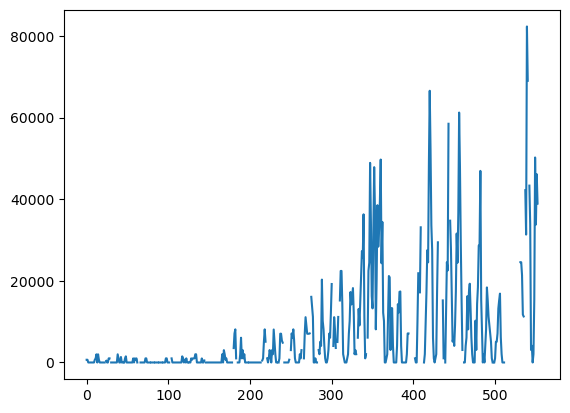

In [8]:
plt.plot(get_species_control_series("PP")[0])

In [9]:
# First we find the 3 most abundant species across the 4 control plots

all_species = df["species"].unique()
total_observed = np.zeros(all_species.shape)
for i, species in enumerate(all_species):
    ts, t = get_species_control_series(species)
    
    total_observed[i] = np.sum(ts, where=np.isfinite(ts))

In [10]:
sorted_indices = np.flip(np.argsort(total_observed))
all_species_sorted = all_species[sorted_indices]
total_observed_sorted = total_observed[sorted_indices]

three_most_abundant = all_species_sorted[:3]

In [11]:
three_most_abundant

array(['DM', 'PP', 'DO'], dtype=object)

DM len: 553
PP len: 553
DO len: 553


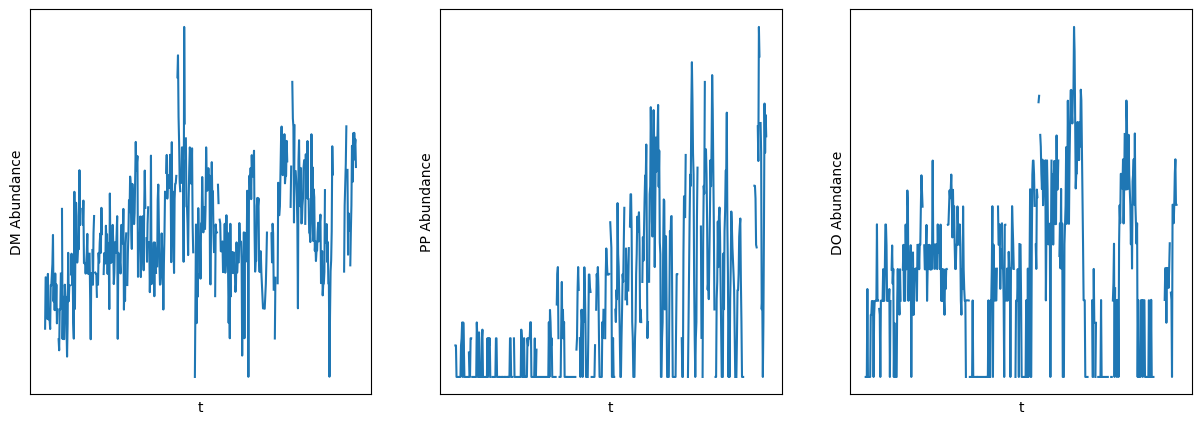

In [12]:
fig_ts, ax_ts = plt.subplots(1,3, figsize=(15,5))

for i, species in enumerate(three_most_abundant):
    ts_raw, t = get_species_control_series(species)
    ts = ns.standardize(np.sqrt(ts_raw))
    
    ax_ts[i].plot(t, ts, label=species)
    ax_ts[i].set_ylabel(species+ " Abundance")
    
    ax_ts[i].set_yticks([])
    ax_ts[i].set_xticks([])
    ax_ts[i].set_xlabel("t")

    print(f"{species} len: {len(ts)}")

In [493]:
E_max = 10
taus = np.arange(1,12)
r_sqrd_table = np.zeros((len(taus), 3))

In [494]:
# Determine tau and E

In [495]:
for i, species in enumerate(three_most_abundant):
    
    ts_raw, t = get_species_control_series(species)
    ts = ns.standardize(np.sqrt(ts_raw))

    r_sqrds = [ns.get_delta_agg(ts, E_max, tau=tau, t=t,
                             return_forecast_skill=True)[2] 
                   for tau in taus]
    r_sqrd_table[:, i] = r_sqrds
    
np.savetxt("../results/portal_rodent_analysis/portal_rodent_rsqrd_vs_tau.csv", r_sqrd_table, delimiter=",")

In [496]:
# Check Autocorrelation

autocorr_table = np.zeros((len(taus),3))

for i, species in enumerate(three_most_abundant):
    ts_raw, t = get_species_control_series(species)
    ts = ns.standardize(np.sqrt(ts_raw))
    ts_noNANs = ts[np.isfinite(ts)]
    
    autocorr_table[:,i] = np.array([np.corrcoef(ts_noNANs[tau:],
                                           ts_noNANs[:-tau])[0,1]
                               for tau in taus])

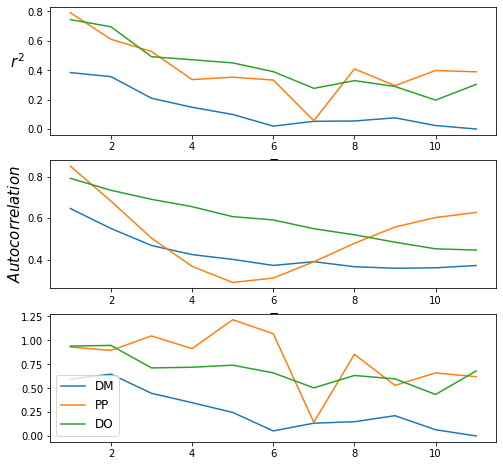

In [497]:
r_sqrd_table = np.loadtxt("../results/portal_rodent_analysis/portal_rodent_rsqrd_vs_tau.csv", delimiter=",")

fig, ax = plt.subplots(3,figsize=(8,8))

for i, species in enumerate(three_most_abundant):
    ax[0].plot(taus, r_sqrd_table[:,i], label=species)
    ax[1].plot(taus, autocorr_table[:,i], label=species)
    ax[2].plot(taus, r_sqrd_table[:,i] / autocorr_table[:,i], label=species)

ax[0].set_ylabel(r"$r^2$", fontsize = 15, rotation = 0, labelpad=10)
ax[0].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)

ax[1].set_xlabel(r"$\tau$", fontsize = 15, rotation = 0)
ax[1].set_ylabel(r"$Auto correlation$", fontsize = 15, rotation = 90)

plt.legend(fontsize = 12)

In [13]:
"""
Tau determination: from the above plot, tau=2 is a great choice because it takes 
the autocorrelation down to 0.7 while preserving a quite strong prediction skill of 
around 0.81.

For E_max, we choose the above 7 the product of that is 49 and that gives a 
decently large embedding window
"""

tau = [2, 2, 2]
E_max = [10, 10, 10]

In [14]:
three_most_abundant

array(['DM', 'PP', 'DO'], dtype=object)

In [514]:
# Finally assess the nonstationarity

for i, species in enumerate(three_most_abundant):
    ts_raw, t = get_species_control_series(species)
    ts = ns.standardize(np.sqrt(ts_raw))
    
    delta, theta, r_sqrd = ns.get_delta_agg(ts, E_max[i], tau=tau[i], t=t,
                                            return_forecast_skill=True)
    print(f"delta = {delta:.2f}, theta = {theta:.2f}, r_sqrd = {r_sqrd:.2f}")

delta = 0.00, theta = 0.00, r_sqrd = 0.36
delta = 9.08, theta = 0.00, r_sqrd = 0.61
delta = 68.38, theta = 0.90, r_sqrd = 0.70


Multiwindow Analysis of DM time series

In [15]:
year_steps = 24
maxLen = ts.shape[0]
lengths = np.arange(year_steps*4,maxLen+1,step=year_steps)

In [16]:
## Compute delta for each subseries, uncomment if you wish to run again
for i, species in enumerate(three_most_abundant):
    ts_raw, t = get_species_control_series(species)
    ts = ns.standardize(np.sqrt(ts_raw))
    
    E = 10
    tau = 2
    h = 0

    # length, starting index, delta, theta, r_sqrd
    n_rows = 210
    results = np.zeros((n_rows, 5))
    tally = 0

    for length in lengths:
        for start in np.arange(0, maxLen - length+1, step=year_steps):
            ts_chunk = ts[start:length+start]
            # plotTS(ts_chunk)
            delta, theta, r_sqrd = ns.get_delta_agg(ts_chunk, E, tau = tau, 
                                                 return_forecast_skill = True)
            results[tally] = np.array([length, start, delta, theta, r_sqrd])
            tally += 1
    np.savetxt(f"../results/portal_rodent_analysis/{species}_time_window.csv",results, fmt="%i,%i,%0.5f,%0.5f,%0.5f")

KeyboardInterrupt: 

In [17]:
evidence_to_probability = lambda ev: (10 ** (ev / 10)) / ((10 ** (ev / 10)) + 1)

# Convert the delta values for each subseries into a square matrix
# which is plotted using matplotlib's imshow.
def makeHeatMapPortal(results):
    nonstationarityHeatMap = np.zeros((20, 20)) * np.nan
    for l, o, e, p, t, d in results:
        i_length = 21-(int(l / year_steps) - 2)
        i_offset = int(o / year_steps)
        
        nonstationarityHeatMap[i_length, i_offset] = p
        
    return nonstationarityHeatMap

In [18]:
# Make the figure
def makeFigurePortal(nonstationarityHeatMap, ts, name, ax):
    
    filenames = {"D. merriami" : "Figure_S16",
                 "PP" : "Figure_S18",
                 "D. ordii" : "Figure_S17"}
    
    scaling = lengths[-1]
    
    # im = ax.imshow(np.zeros(nonstationarityHeatMap[:-2].shape), cmap=cm.Greys)
    im = ax.imshow(nonstationarityHeatMap, cmap=custom_cmap, vmin=0, vmax=1)
    ax.set_xticks(29/24 + 5 * np.arange(8))
    ax.set_yticks(np.arange(21, step=5))
    ax.set_xticklabels([])
    # ax.set_yticklabels((np.flip(lengths)[::5] / 12).astype(int))
    ax.set_ylim(20,-1)
    ax.set_xlim(-1.1, 24.25)
    
    ax.set_ylabel("Time series length (years)",fontsize=15)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label(r"p(NS)",fontsize=15)

    axTS = divider.append_axes('bottom', size='30%', pad=0.1)

    sample_time = np.linspace(7/12 + 1977, 7/12 + 2023, num = 12 * 46 + 1)
    
    axTS.plot(sample_time, ts,c="dodgerblue")
    axTS.set_ylabel(name, fontsize=12, style="italic")
    axTS.set_xlabel("Start year",fontsize=15)
    # axTS.set_xticks(table[::4,0])
    axTS.set_yticks([])
    
    plt.savefig(f"../../figures_eps/portal_multiwindow/{filenames[name]}.eps", format="eps", bbox_inches="tight", transparent=False, facecolor="white")
    plt.show()

In [19]:
# Make a custom orange to blue color scheme
orange_rgba = colors.to_rgba("orange")
dodgerblue_rgba = colors.to_rgba("dodgerblue")
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", [dodgerblue_rgba, orange_rgba]) 
custom_cmap.set_bad("white", 1)

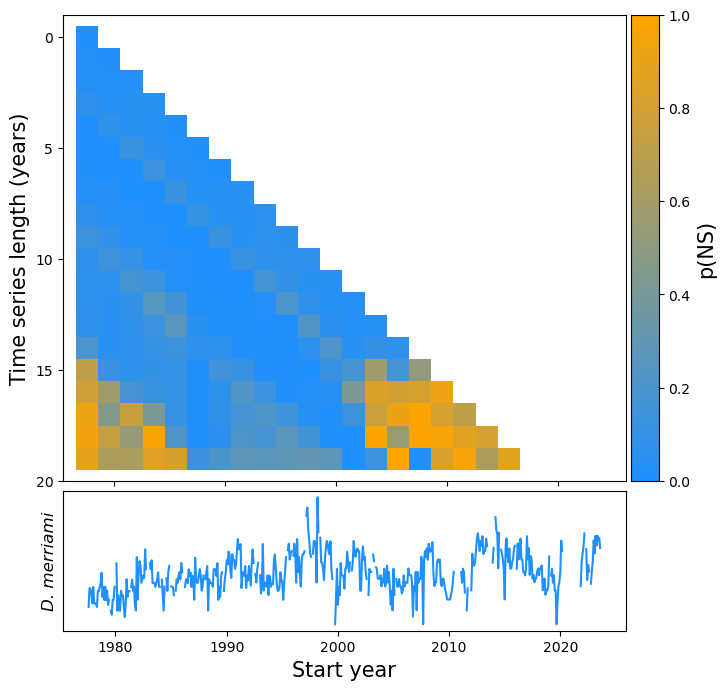

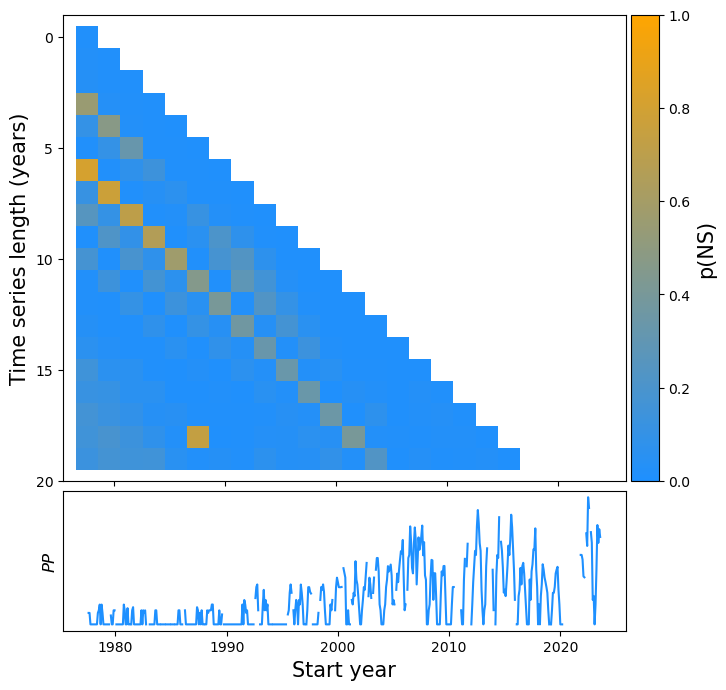

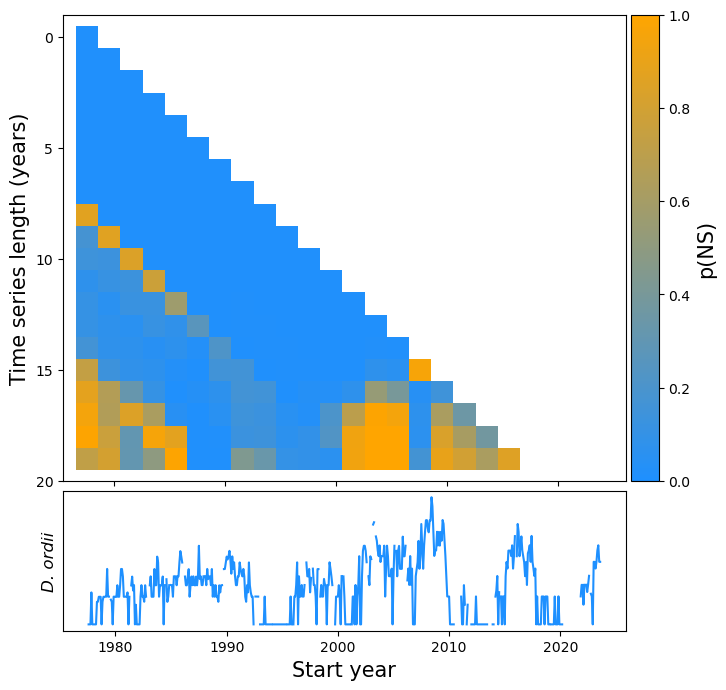

In [20]:
for i, species in enumerate(three_most_abundant):
    
    real_names = ["D. merriami", "PP", "D. ordii"]
    
    ts_raw, t = get_species_control_series(species)
    ts = ns.standardize(np.sqrt(ts_raw))
    
    results = np.loadtxt(f"../../results/portal_rodent_analysis_E_normalized/{species}_time_window.csv",
                             delimiter=",", skiprows=1)

    fig, ax = plt.subplots(1, figsize = (8,8))

    nonstationarityHeatMap = makeHeatMapPortal(results)
    makeFigurePortal(nonstationarityHeatMap, ts, real_names[i], ax)
    
    plt.show()

# Diagnosing

In [23]:
Xr, tx = get_species_control_series("DM")

In [88]:
tau = 1
E_range = [0, 10]
resolution = 4
theta_range = [0.0, 50.0]
delta_range = [0.0, 50.0]

theta_vals = np.linspace(theta_range[0], theta_range[1], resolution)
delta_vals = np.linspace(delta_range[0], delta_range[1], resolution)

log_likelihoods, E_vals, theta_vals, delta_vals = nt._build_log_likelihood_grid(Xr, tx, E_range=E_range, tau=tau,
                                                                                theta_range=theta_vals, delta_range=delta_vals)

In [89]:
e, p = nt.nonstationarity_test((Xr, tx, 1), theta_range, delta_range, E_range, resolution=4)

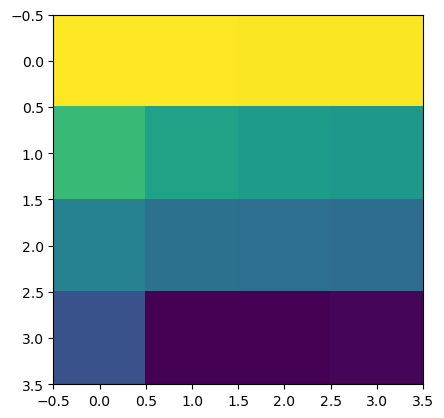

In [91]:
plt.imshow(log_likelihoods[3])

E=1, len(Xemb)=442
E=2, len(Xemb)=403
E=3, len(Xemb)=367
E=4, len(Xemb)=331
E=5, len(Xemb)=301


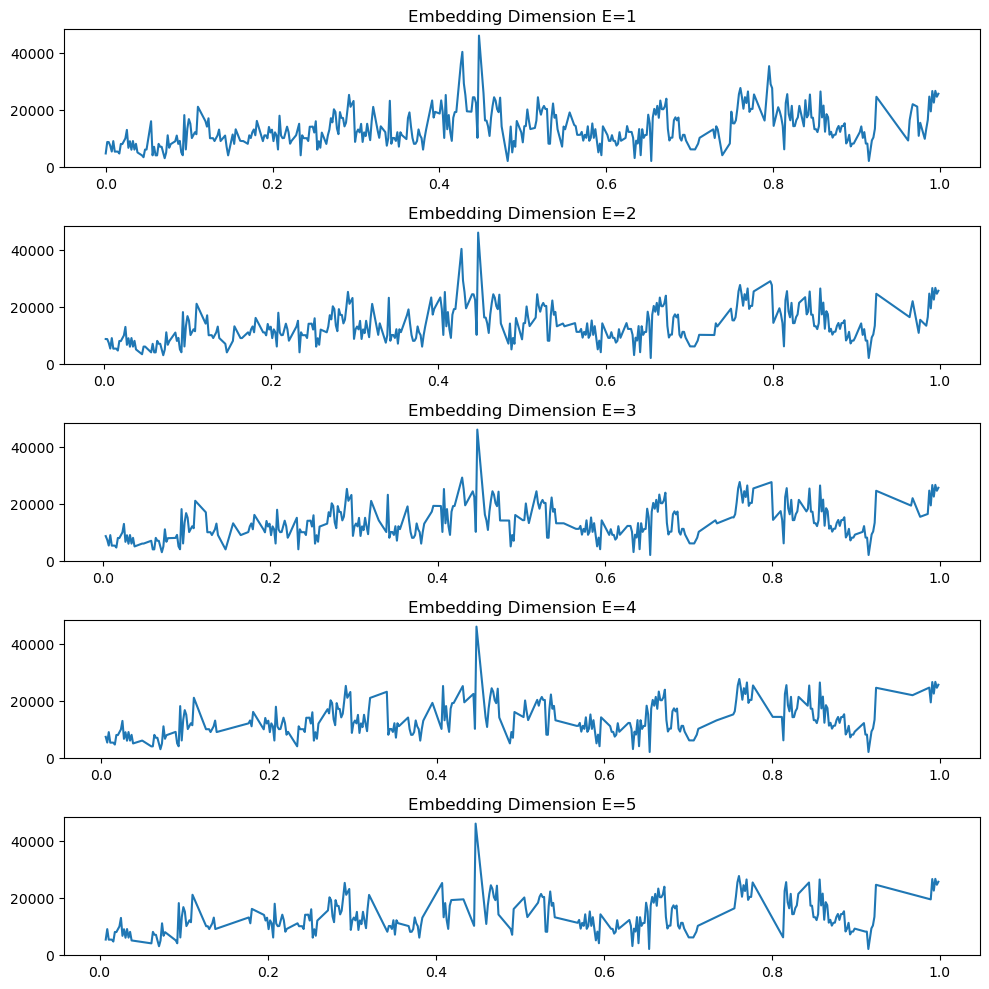

In [46]:
fig, axes = plt.subplots(5, figsize=(10, 10))

lens = []

for E in range(1, 6):
    Xemb, Y, t = ns.delayEmbed(Xr, E, 1, t=tx)

    print(f"E={E}, len(Xemb)={len(Xemb)}")

    lens.append(len(Xemb))

    axes[E-1].plot(t, Xemb[:, 0])
    axes[E-1].set_title(f'Embedding Dimension E={E}')

lens = np.array(lens)

plt.tight_layout()
plt.show()

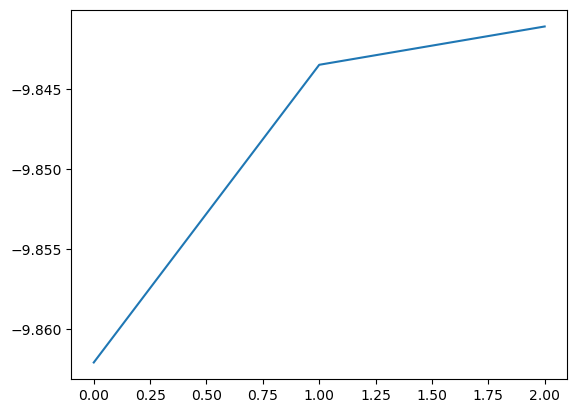

In [52]:
plt.plot(log_likelihoods[1, 0, :])

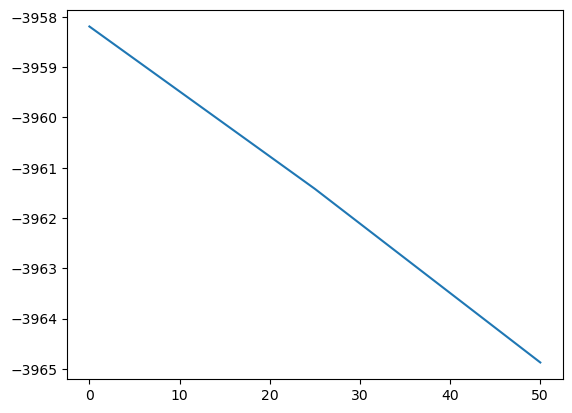

In [44]:
plt.plot(delta_vals, log_likelihoods[2][0])

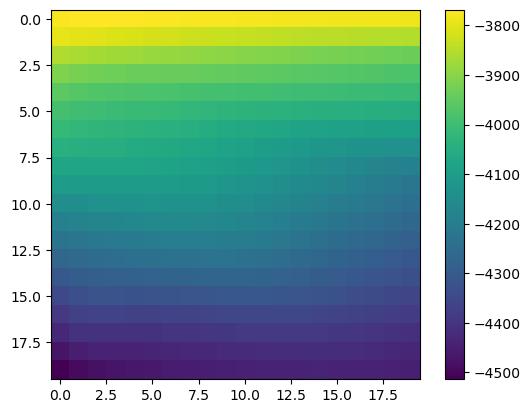

In [150]:
plt.imshow(log_likelihoods[3])
plt.colorbar()

(331, 4)


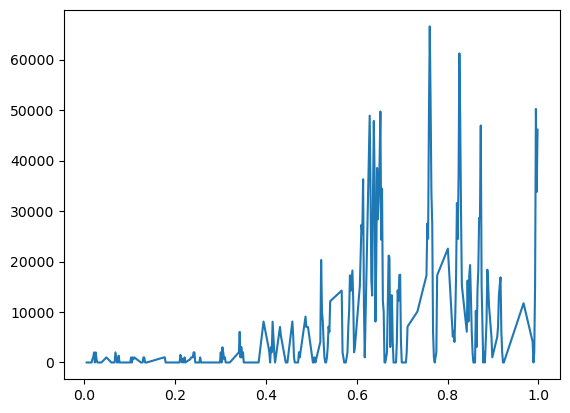

In [148]:
E = 4

Xemb = ns.delayEmbed(Xr, E, 1, t=tx)

print(Xemb[0].shape)
plt.plot(Xemb[-1], Xemb[0][:, 0])

In [149]:
plt.plot(log_likelihoods[E, 0])

IndexError: index 4 is out of bounds for axis 0 with size 4